# Система обнаружения стеганографии с помощью нейросети Zhu-Net (SOTA) для обнаружения LSB-встраивания

С использованием датасета  с 256 пустыми изображениями и датасета с 256 классическим LBS-replacement

Разделеления для обучения:
   
- Всего изображений: 512 (256 Cover + 256 Stego).
- Тест:  512×0.2=102.4≈104 изображения.
- Обучение: 512−104=408 изображений.
- Формат данных: PNG, grayscale, 256×256

Архитектура: фиксированный банк высокочастотных фильтров (SRM-like) → сверточные блоки с TLU-активацией → Global Average Pooling → бинарная классификация

**Установка и подключение диска**

In [1]:
# 1. Подключение Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. Установка библиотек
!pip -q install --upgrade pip
!pip -q install torch torchvision albumentations opencv-python-headless tqdm pandas scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 74.8 MB/s eta 0:00:00


In [3]:
# 3. Импорты
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [4]:
# 4. Фиксация seed

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
# 5. Пути к датасету
COVER_DIR = Path("/content/drive/MyDrive/FQW/grayscale_dataset")
STEGO_DIR = Path("/content/drive/MyDrive/FQW/grayscale_dataset_LSB")

ALLOWED_EXTS = {".png"}

print("COVER_DIR exists:", COVER_DIR.exists())
print("STEGO_DIR exists:", STEGO_DIR.exists())

COVER_DIR exists: True
STEGO_DIR exists: True


In [6]:
# 6. Индексация изображений

def list_images(folder: Path, allowed_exts=ALLOWED_EXTS):
    if not folder.exists():
        return []
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in allowed_exts
    ])

cover_paths = list_images(COVER_DIR)
stego_paths = list_images(STEGO_DIR)

print("Cover images:", len(cover_paths))
print("Stego images:", len(stego_paths))

if len(cover_paths) != 256 or len(stego_paths) != 256:
    print("Внимание: ожидалось 256 clean и 256 stego изображений.")

rows = []

for p in cover_paths:
    rows.append({"path": str(p), "label": 0})

for p in stego_paths:
    rows.append({"path": str(p), "label": 1})

df = pd.DataFrame(rows)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Всего изображений:", len(df))
print(df["label"].value_counts())
df.head()

Cover images: 256
Stego images: 256
Всего изображений: 512
label
1    256
0    256
Name: count, dtype: int64


,path,label
0,/content/drive/MyDrive/FQW/grayscale_dataset_L...,1
1,/content/drive/MyDrive/FQW/grayscale_dataset_L...,1
2,/content/drive/MyDrive/FQW/grayscale_dataset_L...,1
3,/content/drive/MyDrive/FQW/grayscale_dataset/g...,0
4,/content/drive/MyDrive/FQW/grayscale_dataset_L...,1


In [7]:
# 7. Разбиение на train/test

train_df, test_df = train_test_split(
    df,
    test_size=104,
    stratify=df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("\nTrain label counts:")
print(train_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

Train size: 408
Test size: 104

Train label counts:
label
0    204
1    204
Name: count, dtype: int64

Test label counts:
label
0    52
1    52
Name: count, dtype: int64


In [8]:
# 8. Трансформации

IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

In [9]:
# 9. Dataset. Модель получает только пиксели.

class StegoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        label = np.float32(row["label"])

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise RuntimeError(f"Не удалось прочитать изображение: {path}")

        if self.transform:
            img = self.transform(image=img)["image"]
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0

        return img, torch.tensor(label, dtype=torch.float32)

In [10]:
# 10. DataLoader

BATCH_SIZE = 32

train_dataset = StegoDataset(train_df, transform=train_transform)
test_dataset  = StegoDataset(test_df, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 13
Test batches: 4


In [11]:
# 11. Блок SE Attention

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.pool(x).view(b, c)
        w = F.relu(self.fc1(w), inplace=True)
        w = torch.sigmoid(self.fc2(w)).view(b, c, 1, 1)
        return x * w

In [12]:
# 12. Residual Block для Zhu-Net

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_se=True):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.use_se = use_se
        self.se = SEBlock(out_channels) if use_se else nn.Identity()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = self.se(out)

        out = out + identity
        out = F.relu(out, inplace=True)
        return out

In [13]:
# 13. Модель Zhu-Net

class ZhuNet(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.layer1 = nn.Sequential(
            ResidualBlock(32, 32, stride=1, use_se=True),
            ResidualBlock(32, 32, stride=1, use_se=True)
        )

        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64, stride=2, use_se=True),
            ResidualBlock(64, 64, stride=1, use_se=True)
        )

        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, use_se=True),
            ResidualBlock(128, 128, stride=1, use_se=True)
        )

        self.layer4 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, use_se=True),
            ResidualBlock(256, 256, stride=1, use_se=True)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [14]:
# 14. Инициализация

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memory:", round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2), "GB")

model = ZhuNet(in_channels=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("\nМодель загружена на", device)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 39.49 GB

Модель загружена на cuda


In [15]:
# 15. Функции обучения и оценки

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            total_loss += loss.item() * images.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    return avg_loss, acc, auc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [16]:
# 16. Обучение

train_sub_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=SEED
)

train_sub_df = train_sub_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train_sub:", len(train_sub_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train_sub: 326
Val: 82
Test: 104


In [17]:
# 17. Loader для validation

train_dataset = StegoDataset(train_sub_df, transform=train_transform)
val_dataset   = StegoDataset(val_df, transform=test_transform)
test_dataset  = StegoDataset(test_df, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [18]:
# 18. Основной цикл обучения

EPOCHS = 25
best_val_auc = 0.0
best_model_path = "/content/zhu_lsb_best.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

print("=" * 60)
print("НАЧАЛО ОБУЧЕНИЯ Zhu-Net")
print("=" * 60)
print(f"Эпох: {EPOCHS}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_auc, _, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.4f}")
    print(f"Val AUC:    {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_model_path)

print("\nОБУЧЕНИЕ ЗАВЕРШЕНО")
print("=" * 60)
print(f"Лучший AUC на валидации: {best_val_auc:.4f}")

НАЧАЛО ОБУЧЕНИЯ Zhu-Net
Эпох: 25
Learning rate: 0.001
Batch size: 32
Image size: 256x256


Train:   0%|          | 0/11 [00:00<?, ?it/s]

Eval:   0%|          | 0/3 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b9011243740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
   Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7b9011243740> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
^ ^ ^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^^ ^ ^ ^ ^  ^^  
^  File "/us


Epoch 1/25
Train Loss: 0.8730
Val Loss:   0.7032
Val Acc:    0.5244
Val AUC:    0.4408


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b9011243740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b9011243740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Epoch 24/25
Train Loss: 0.7042
Val Loss:   0.7185
Val Acc:    0.4390
Val AUC:    0.4307


Train:   0%|          | 0/11 [00:00<?, ?it/s]

Eval:   0%|          | 0/3 [00:00<?, ?it/s]


Epoch 25/25
Train Loss: 0.7060
Val Loss:   0.6977
Val Acc:    0.4878
Val AUC:    0.4997

ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучший AUC на валидации: 0.5247


In [19]:
# 19.  Загрузка лучшей модели
model.load_state_dict(torch.load(best_model_path, map_location=device))
print("Загружена лучшая модель.")

Загружена лучшая модель.


In [21]:
# 20. Тестирование

print("\n" + "=" * 60)
print("ТЕСТИРОВАНИЕ НА ТЕСТОВОМ НАБОРЕ")
print("=" * 60)

test_loss, test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion, device)

print(f"\nTest Loss:  {test_loss:.4f}")
print(f"Test Acc:   {test_acc:.4f}")
print(f"Test AUC:   {test_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Clean", "Stego"]))


ТЕСТИРОВАНИЕ НА ТЕСТОВОМ НАБОРЕ


Eval:   0%|          | 0/4 [00:00<?, ?it/s]


Test Loss:  0.7206
Test Acc:   0.4615
Test AUC:   0.4397

Classification Report:
              precision    recall  f1-score   support

       Clean       0.46      0.46      0.46        52
       Stego       0.46      0.46      0.46        52

    accuracy                           0.46       104
   macro avg       0.46      0.46      0.46       104
weighted avg       0.46      0.46      0.46       104



In [22]:
# 21. Матрица ошибок

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[24 28]
 [28 24]]


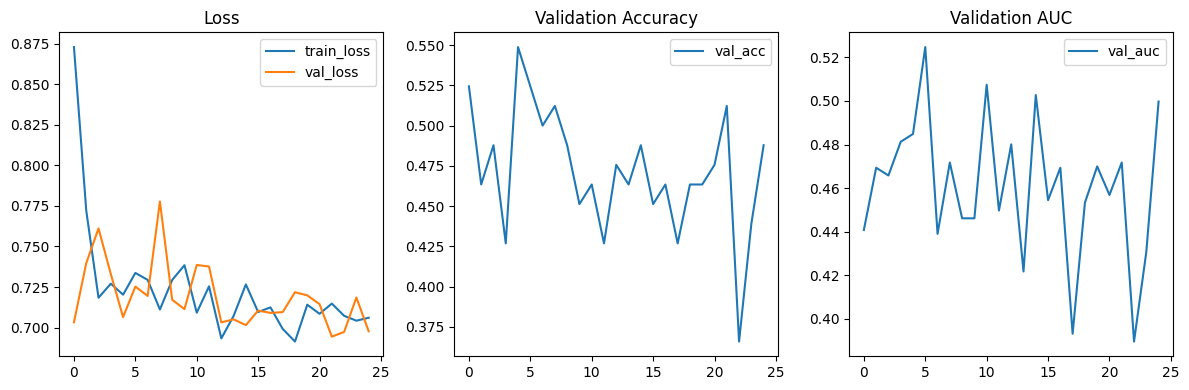

In [23]:
# 22. Графики обучения

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["val_acc"], label="val_acc")
plt.title("Validation Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["val_auc"], label="val_auc")
plt.title("Validation AUC")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# 23. Сохранение финальной модели

final_model_path = "/content/zhu_final_model.pth"
torch.save(model.state_dict(), final_model_path)
print("Финальная модель сохранена:", final_model_path)

Финальная модель сохранена: /content/zhu_final_model.pth


**Общий вывод:**

Ключевые цифры:

Val AUC max ≈ 0.5247

Test AUC ≈ 0.4397

Accuracy ≈ 0.46

**Вывод по эксперименту**

- В ходе экспериментального исследования было установлено, что применение архитектуры Zhu-Net к синтетическому датасету, состоящему из однородных изображений с внедрением информации методом LSB-replacement, не приводит к формированию устойчивой модели стегоанализа. Полученные значения метрик (ROC-AUC ≈ 0.44–0.52, Accuracy ≈ 0.46) свидетельствуют о том, что модель не способна различать классы и фактически работает на уровне случайного угадывания.

- Данный результат объясняется отсутствием выраженных статистических признаков в исходных изображениях, малым объёмом обучающей выборки, а также слабостью сигнала, формируемого при однобитном LSB-встраивании. Это подтверждает необходимость использования более сложных структур данных, специализированных методов предварительной обработки (например, SRM-фильтров), а также увеличения объёма обучающей выборки для успешного применения нейронных сетей в задачах стегоанализа.